# Topic 1: Introduction to Transfer Learning & Why It Matters

---

## 1. Introduction

**What is Transfer Learning?**

Transfer Learning is a machine learning technique where you take a model that has already been trained on one dataset and apply (or "transfer") that knowledge to a different but related dataset or task.

**Real-life analogy:** 
- If you know how to ride a bicycle, learning to ride a motorcycle becomes easier because you already understand balancing.
- If you can play the violin, picking up the guitar is simpler because you already understand musical notes and rhythm.

Your brain transfers knowledge from one related task to another — that's exactly what Transfer Learning does for AI models.

**Why is it important?**

It has become a **"big deal" in machine learning since 2015-2016**. Industry experts consider it the next big thing that will drive machine learning forward — second only to supervised learning in impact.

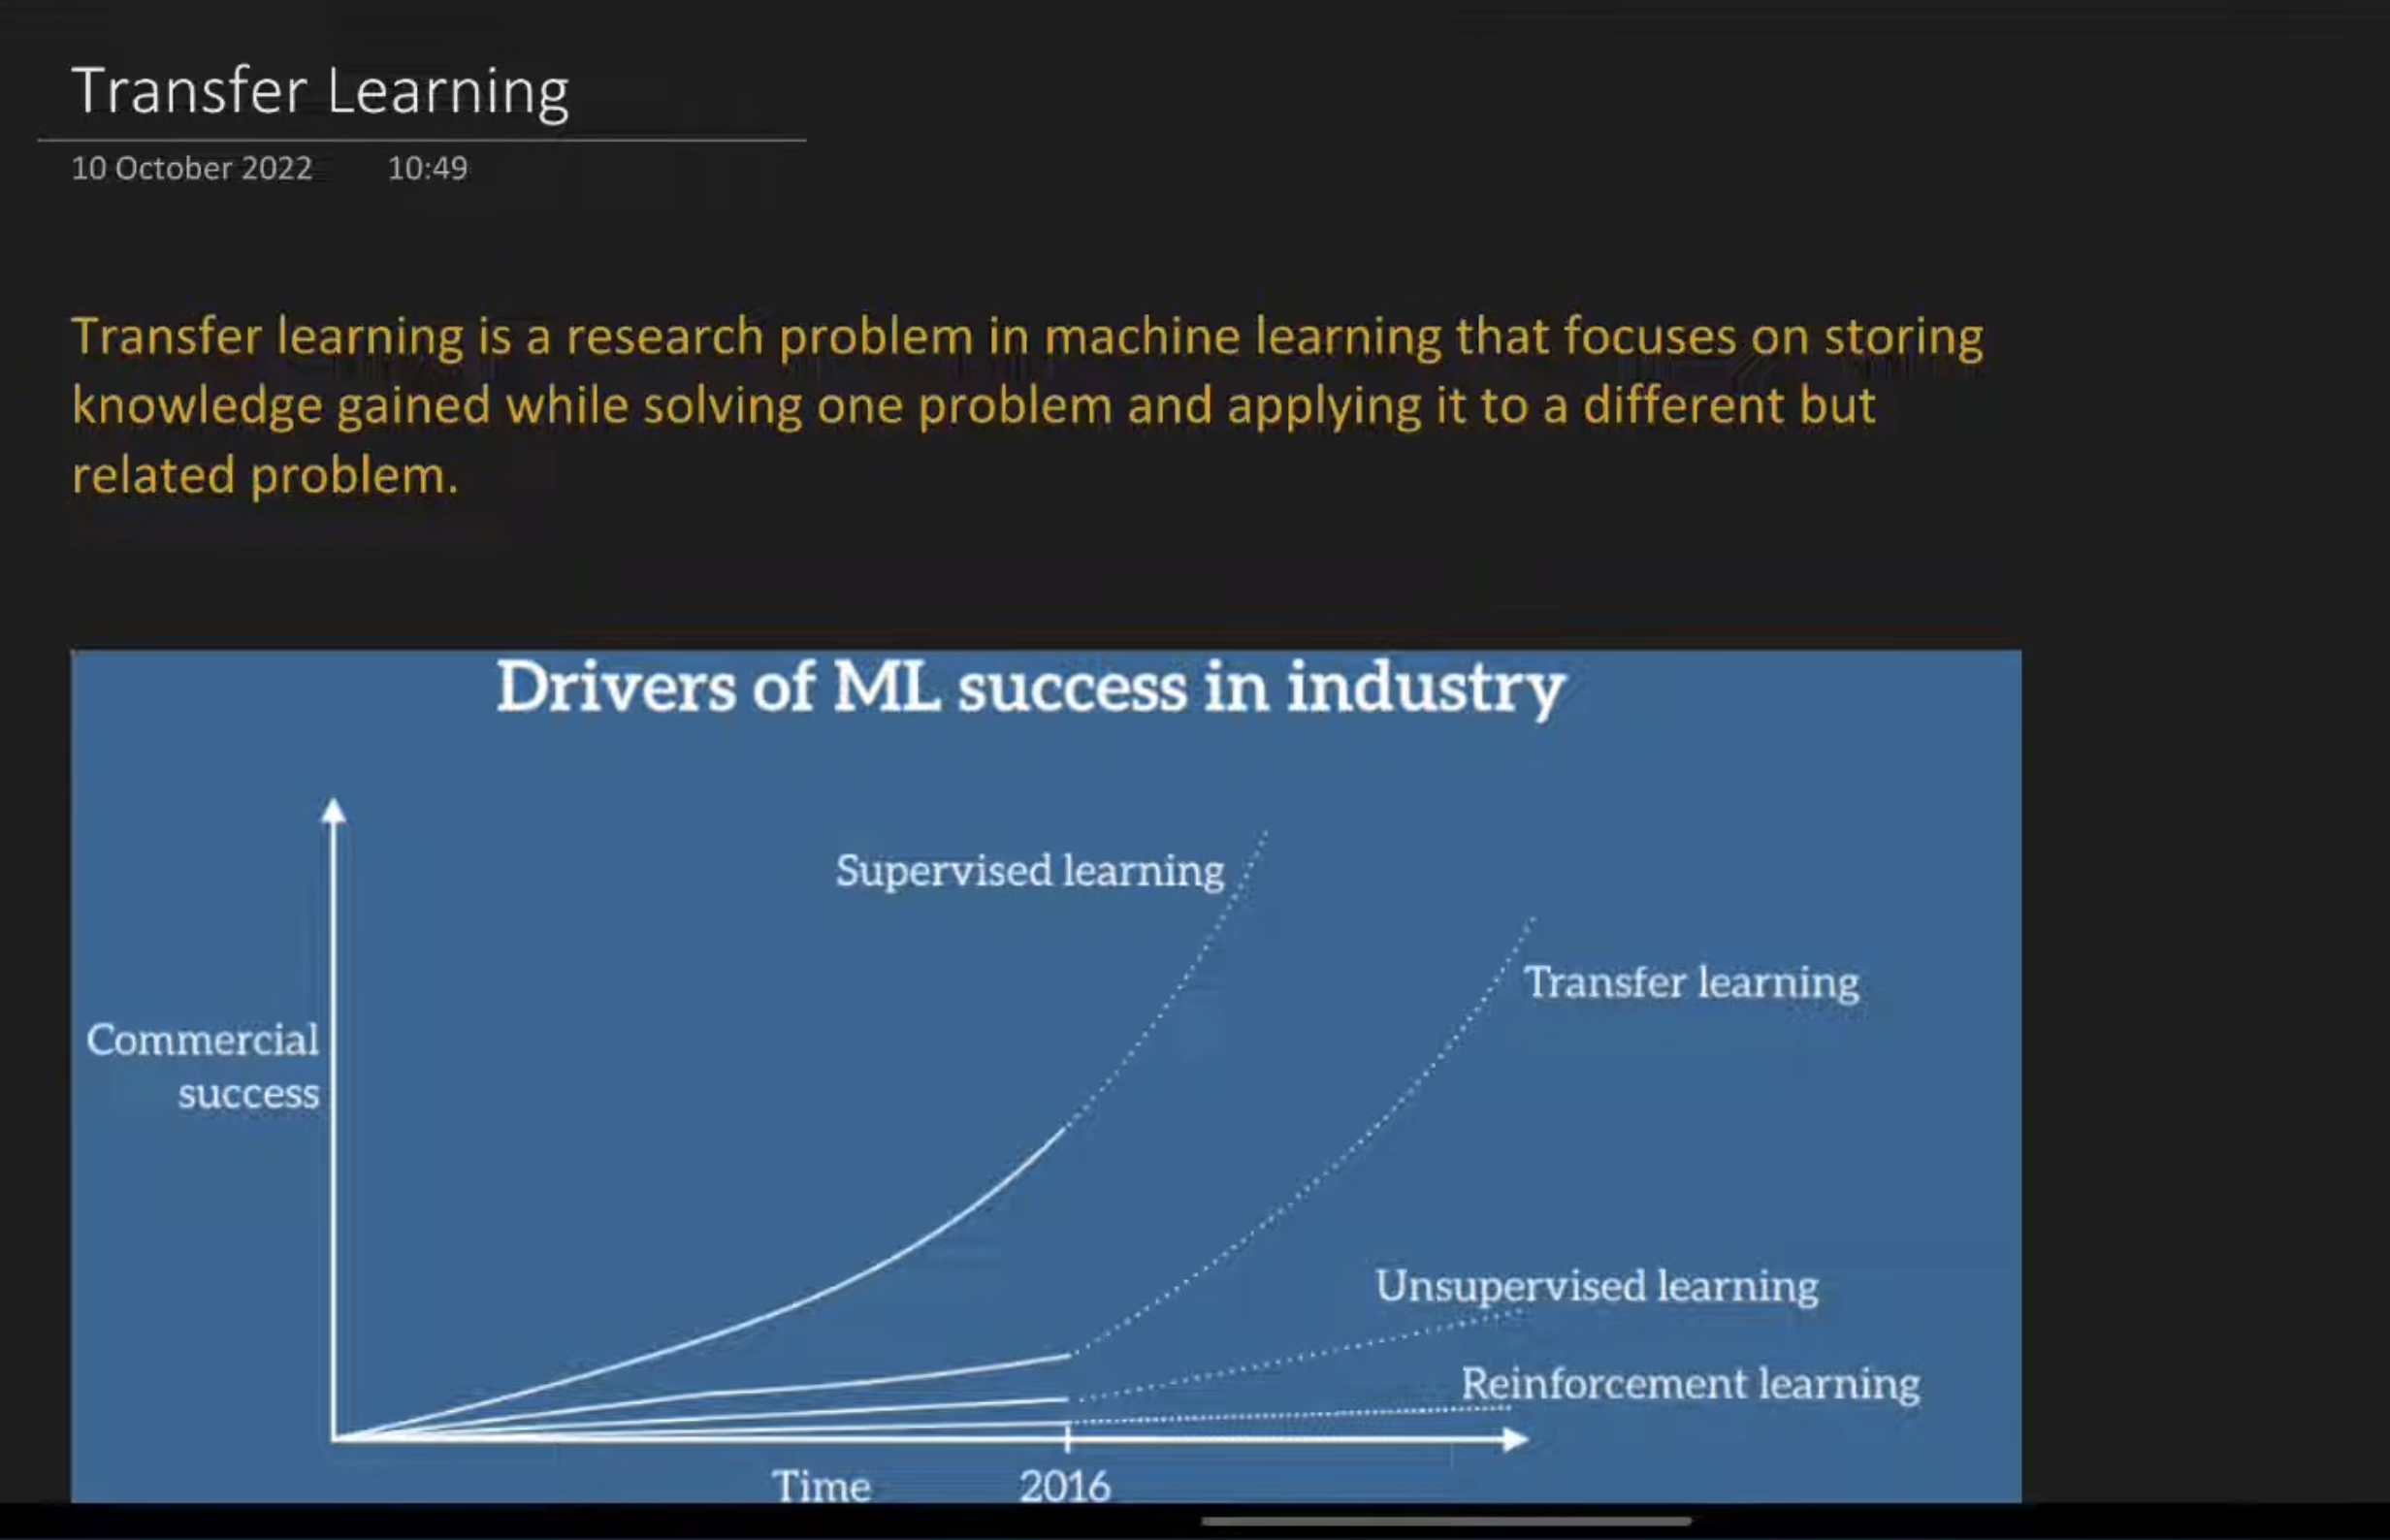

---

## 2. Detailed Explanation

### The Problem Transfer Learning Solves

Training your own deep learning model from scratch has **two major challenges**:

| Challenge | Why It's a Problem |
|-----------|-------------------|
| **Data Hunger** | Deep learning models need massive amounts of labeled data (e.g., 10,000+ images). Collecting and labeling data is expensive, time-consuming, and requires manual labor. |
| **Training Time** | Training on large datasets takes enormous computational time. |

> **Because of these two problems, most people prefer NOT to train their own deep learning models from scratch.**

### The Solution: Pre-trained Models

A **pre-trained model** is a CNN model that has already been trained on a large dataset like **ImageNet**.

**What is ImageNet?**
- A massive dataset with about **1.4 million images**
- Contains **1000 different categories** (daily objects, animals, dog breeds, etc.)
- Used in the **ILSVRC** (ImageNet Large Scale Visual Recognition Challenge) starting from 2010

Popular pre-trained models that won this competition include:
- VGG16
- ResNet
- InceptionNet

> You can "pick up" these models and use them directly in your projects!

### But There's Still a Problem

What if your specific project is **not** one of those 1000 classes?

**Example:** You want to build a classifier that distinguishes between **phones and tablets**. 
- ImageNet has 1000 classes, but "phone" and "tablet" may not be in those classes
- You need to adapt the model to your specific task

**This is exactly where Transfer Learning comes in!**

### How Transfer Learning Works (Step-by-Step)

Let's use **VGG16** (a famous CNN model) trained on ImageNet as an example:

```
┌─────────────────────────────────────────────────────────────┐
│                      VGG16 Architecture                     │
├─────────────────────────────┬───────────────────────────────┤
│                             │                               │
│    CONVOLUTION BASE         │     FULLY CONNECTED (FC)      │
│    (Feature Extractor)      │     (Classifier)              │
│                             │                               │
│  - Conv layers              │  - Dense layers               │
│  - Pooling layers           │  - Output layer (1000 classes)│
│  - Captures patterns        │                               │
│    from images              │                               │
│                             │                               │
└─────────────────────────────┴───────────────────────────────┘
```

**To apply Transfer Learning:**

1. **Remove the FC (classifier) part** — the last dense layers and output layer
2. **Replace it with your own custom dense layers** based on your problem:
   - For binary classification (phone vs tablet): Add an output layer with **1 neuron** and **sigmoid** activation
   - For multi-class: Add output layer with **N neurons** and **softmax**
3. **Freeze the convolution base** — this prevents their weights from being retrained (we don't want to "unlearn" what was already learned)
4. **Train only the new dense layers** on your smaller dataset

### Why Does This Work?

The **convolution layers** learn hierarchical features:

| Layer Type | What It Learns |
|------------|---------------|
| **Early layers** | Primitive features: edges, corners, colors, simple textures |
| **Middle layers** | More complex patterns: shapes, object parts (eyes, wheels) |
| **Later layers** | High-level features: full object representations |

Since **ImageNet contains 1000 diverse classes**, the model has already learned **general, reusable features** (edges, textures, shapes) that are common to almost any image.

> **Key insight:** You don't need to "reinvent the wheel" — the model has already learned universal visual features. You just need to adapt the final classifier to your specific task.

---

## 3. Key Points

- ✅ Transfer Learning = taking knowledge from one task and applying it to a related task
- ✅ It saves you from needing **massive labeled datasets**
- ✅ It saves **training time** and **computational resources**
- ✅ Pre-trained models like VGG16, ResNet, and InceptionNet are readily available
- ✅ The **convolution base** extracts features; the **FC layers** classify
- ✅ You **freeze** the convolution base and only train new custom dense layers
- ✅ This approach works because early layers learn **general features** that are useful across many tasks

---

## 4. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|---------------|--------------|
| **Training the entire model from scratch** | Wastes time and data; defeats the purpose of transfer learning | Freeze the convolution base |
| **Not freezing the convolution base** | You'll "unlearn" the valuable features already learned on ImageNet | Set `trainable = False` on the base model |
| **Using too many custom dense layers** | Can cause overfitting with small datasets | Start with 1-2 dense layers + output layer |
| **Using the wrong activation function** | Binary classification needs sigmoid; multi-class needs softmax | Match activation to your problem type |

---

## 5. Interview / Exam Questions

**Q1: What is Transfer Learning in simple terms?**
> Taking a model trained on one dataset and reusing it on a different but related task, instead of training from scratch.

**Q2: Why is Transfer Learning useful in deep learning?**
> Because training from scratch requires massive labeled data and enormous compute time. Transfer Learning leverages pre-trained models to solve new tasks with less data and time.

**Q3: What is a pre-trained model? Give examples.**
> A CNN model already trained on a large dataset like ImageNet. Examples: VGG16, ResNet, InceptionNet.

**Q4: What are the two main parts of a CNN used in Transfer Learning?**
> 1. **Convolution Base** — extracts features from images
> 2. **Fully Connected (FC) Layers** — performs classification

**Q5: Why can we reuse the convolution base for different tasks?**
> Because early layers learn general, primitive features (edges, textures, shapes) that are common to almost all images — not specific to the original dataset.

---

## 6. Revision Notes

| Concept | Quick Recap |
|---------|-------------|
| **Transfer Learning** | Reuse knowledge from one task to another |
| **Pre-trained Model** | Model already trained on large dataset (e.g., ImageNet) |
| **ImageNet** | 1.4M images, 1000 classes, used in ILSVRC |
| **VGG16 / ResNet / InceptionNet** | Famous pre-trained CNN architectures |
| **Convolution Base** | Feature extractor — FREEZE this |
| **FC Layers** | Classifier — REPLACE with your own |
| **Why it works** | Universal features learned are reusable |
| **Key benefit** | Less data, less time, less compute needed |

---

**That covers the first topic: Introduction to Transfer Learning & Why It Matters.**


# Topic 2: Feature Extraction vs Fine Tuning (The Two Key Transfer Learning Techniques)

---

## 1. Introduction

When applying Transfer Learning, you have **two main approaches** to choose from:

1. **Feature Extraction**
2. **Fine Tuning**

Both techniques use a pre-trained model, but they differ in **which parts of the model you retrain** and **how much of the model's knowledge you modify**.

Think of it like learning a new skill:
- **Feature Extraction** = Using your existing knowledge exactly as-is, just applying it in a new context
- **Fine Tuning** = Using your existing knowledge but tweaking/adjusting it slightly for the new context

---

## 2. Detailed Explanation

### Technique 1: Feature Extraction

**What is Feature Extraction?**

In Feature Extraction, you:
- **Freeze the entire convolution base** (all convolutional layers are locked)
- **Remove the original FC (classifier) layers**
- **Add your own custom dense layers** on top
- **Train ONLY your new dense layers** — the convolution base does NOT change

```
┌─────────────────────────────────────────────────────────────────┐
│                    FEATURE EXTRACTION                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   ┌──────────────────┐     ┌─────────────────────┐             │
│   │  CONVOLUTION     │     │   YOUR CUSTOM       │             │
│   │  BASE            │────▶│   FC LAYERS         │             │
│   │  (FROZEN)        │     │   (TRAINABLE)       │             │
│   └──────────────────┘     └─────────────────────┘             │
│         🔒                        🔓                           │
│   Weights don't change       These layers learn               │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

**When should you use Feature Extraction?**

✅ **When your dataset is similar to ImageNet's categories**
- Example: You're doing **dog vs cat** classification
- ImageNet already contains animals, so the features learned are highly relevant
- You only need to adapt the final classifier

✅ **When you have very little data**
- Training fewer parameters (only the dense layers) requires less data
- Less risk of overfitting

### Technique 2: Fine Tuning

**What is Fine Tuning?**

In Fine Tuning, you:
- **Unfreeze SOME of the later convolutional layers**
- **Keep the early convolutional layers frozen**
- **Remove the original FC layers** and add your custom layers
- **Train the entire model** (unfrozen layers + custom layers)

```
┌─────────────────────────────────────────────────────────────────┐
│                      FINE TUNING                               │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│   ┌────────────────┐  ┌────────────────┐  ┌───────────────┐   │
│   │  EARLY         │  │  LATER         │  │  YOUR CUSTOM  │   │
│   │  CONV LAYERS   │──▶  CONV LAYERS   │──▶  FC LAYERS    │   │
│   │  (FROZEN)      │  │  (UNFROZEN)    │  │  (TRAINABLE)  │   │
│   └────────────────┘  └────────────────┘  └───────────────┘   │
│         🔒                     🔓                   🔓        │
│   Keep these fixed      Retrain these      Learn new          │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

**Why unfreeze only later layers?**

| Layer Position | What They Learn | Should You Retrain? |
|----------------|-----------------|---------------------|
| **Early layers** | Primitive features: edges, colors, simple textures | ❌ No — these are universal for all images |
| **Middle layers** | Mid-level patterns: shapes, object parts | ⚠️ Maybe — depends on task similarity |
| **Later layers** | High-level, task-specific features | ✅ Yes — these are most different from your task |

**When should you use Fine Tuning?**

✅ **When your dataset is very different from ImageNet**
- Example: **Phone vs Tablet** classification
- ImageNet may not contain these specific electronics
- Later layers need to learn new high-level features

✅ **When you have enough data** (still less than training from scratch)
- Training more parameters requires more data

✅ **When you want higher accuracy**
- Fine tuning often gives better results than feature extraction

### Important Rule for Fine Tuning

> **Always do Feature Extraction FIRST, then Fine Tuning.**

**Why?**
1. Train the new dense layers first (Feature Extraction)
2. Then unfreeze later layers and train with a **lower learning rate**
3. This prevents destroying the already-learned useful features

**Learning Rate Tip:**
- For Fine Tuning, use a **lower learning rate** (e.g., 0.0001 or even lower)
- The model already has good weights — you want to tweak them gently, not drastically change them

---

## 3. Comparison Table: Feature Extraction vs Fine Tuning

| Aspect | Feature Extraction | Fine Tuning |
|--------|-------------------|-------------|
| **What gets trained** | Only new FC layers | Later conv layers + new FC layers |
| **Convolution base** | Fully FROZEN | Partially UNFROZEN |
| **Training time** | Faster | Slower |
| **Data needed** | Less | More |
| **Best for** | Similar tasks, small datasets | Different tasks, larger datasets |
| **Accuracy potential** | Good | Potentially higher |
| **Risk** | Lower overfitting | Higher overfitting |
| **Learning rate** | Normal | Lower |

---

## 4. Implementation Example (Conceptual Code)

### Feature Extraction Implementation

```python
# Load pre-trained VGG16 without the top (classifier) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# FREEZE the convolution base
base_model.trainable = False  # <-- THIS IS FEATURE EXTRACTION

# Add your custom dense layers on top
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Now only the new dense layers will be trained
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
```

### Fine Tuning Implementation

```python
# Load pre-trained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# FREEZE early layers first
base_model.trainable = False

# Add your custom dense layers (Feature Extraction first!)
model = Sequential([base_model, Flatten(), Dense(256, activation='relu'), Dense(1, activation='sigmoid')])

# TRAIN the dense layers first (Feature Extraction step)
model.fit(train_data, epochs=10)

# NOW for Fine Tuning:
# Unfreeze the later layers (e.g., block5 onwards)
base_model.trainable = True
for layer in base_model.layers:
    if layer.name.startswith('block5'):  # Only train later layers
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with lower learning rate
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train again with more epochs
model.fit(train_data, epochs=10)
```

---

## 5. Code Explanation (Line by Line)

| Code | Purpose |
|------|---------|
| `base_model = VGG16(weights='imagenet', include_top=False)` | Load VGG16 without the FC layers, using ImageNet weights |
| `base_model.trainable = False` | FREEZE all layers — no retraining |
| `model = Sequential([base_model, Flatten(), ...])` | Build new model with base + custom layers |
| `layer.trainable = True` | UNFREEZE a specific layer for Fine Tuning |
| `optimizer=Adam(learning_rate=0.0001)` | Lower learning rate for Fine Tuning |

---

## 6. Common Mistakes

| Mistake | How to Avoid |
|---------|-------------|
| **Fine Tuning from the start without Feature Extraction first** | Always train custom layers first, then fine-tune |
| **Using normal/high learning rate for Fine Tuning** | Use a lower learning rate (e.g., 0.0001) to avoid destroying useful features |
| **Unfreezing ALL layers** | Only unfreeze later layers; early layers have universal features |
| **Fine Tuning with very little data** | Stick to Feature Extraction if you have < 1000 samples per class |
| **Forgetting to recompile after changing `trainable`** | Always recompile the model after changing trainable status |

---

## 7. Interview / Exam Questions

**Q1: What is the difference between Feature Extraction and Fine Tuning?**

| Feature Extraction | Fine Tuning |
|-------------------|-------------|
| Freeze entire convolution base | Unfreeze some later conv layers |
| Only train new FC layers | Train later conv layers + new FC layers |
| Faster, less data needed | Slower, more data needed |

**Q2: When would you use Feature Extraction instead of Fine Tuning?**
> When your dataset is similar to ImageNet (e.g., animal classification) and/or you have a small dataset.

**Q3: When would you use Fine Tuning?**
> When your dataset is different from ImageNet (e.g., phone vs tablet) and you have enough data to train more parameters.

**Q4: Why should we use a lower learning rate for Fine Tuning?**
> Because the model already has good weights. A lower learning rate makes small, gentle adjustments instead of drastically changing the weights.

**Q5: Why do we only unfreeze later layers, not early layers, during Fine Tuning?**
> Early layers learn primitive, universal features (edges, colors) that are useful for ALL images. Later layers learn task-specific, high-level features that need adjustment for your specific task.

---

## 8. Revision Notes

| Concept | Summary |
|---------|---------|
| **Feature Extraction** | Freeze base → add new layers → train only new layers |
| **Fine Tuning** | Freeze base → add layers → train new layers → unfreeze later layers → retrain with low LR |
| **Rule of thumb** | Feature Extraction first, then Fine Tuning if needed |
| **Learning Rate** | Lower for Fine Tuning (0.0001) vs normal for Feature Extraction |
| **When to use each** | FE = similar tasks, small data; FT = different tasks, larger data |
| **Why later layers** | They learn task-specific features; early layers are universal |

---

**That covers the second topic: Feature Extraction vs Fine Tuning.**



# Topic 3: Code Implementation & Practical Walkthrough (Feature Extraction)

---

## 1. Introduction

Now that you understand the theory, let's see **how to actually implement Transfer Learning in code** using Keras (TensorFlow).

The transcript walks through three different notebooks:
1. **Feature Extraction without Data Augmentation**
2. **Feature Extraction with Data Augmentation**
3. **Fine Tuning**

We'll cover the practical implementation step-by-step, explaining every line of code and what results to expect.

**What you'll see in practice:**
- Custom CNN from scratch gave ~**81%** accuracy
- Feature Extraction gave ~**90%** accuracy
- With Data Augmentation, accuracy improved to ~**91.4%**
- Fine Tuning gave even better results at ~**95.2%**

---

## 2. Detailed Explanation – Feature Extraction Implementation

### Step 1: Import Libraries and Load Data

```python
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Flatten, Dense
from keras.preprocessing.image import ImageDataGenerator
```

**Explanation:**
| Import | Purpose |
|--------|---------|
| `VGG16` | The pre-trained model we'll use (trained on ImageNet) |
| `Sequential` | To build our model layer-by-layer |
| `Flatten, Dense` | Layers for our custom classifier |
| `ImageDataGenerator` | Utility to load images from folders |

---

### Step 2: Load the Pre-trained Model

```python
# Load VGG16 without the top (classifier) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
```

**Line-by-line breakdown:**
| Parameter | Value | Purpose |
|-----------|-------|---------|
| `weights` | `'imagenet'` | Load weights pre-trained on ImageNet dataset |
| `include_top` | `False` | Don't include the original FC/classifier layers |
| `input_shape` | `(150, 150, 3)` | Specify input image size (height, width, channels) |

> 💡 **Why `include_top=False`?**  
> We want to **replace** the original classifier with our own custom layers for our specific problem.

---

### Step 3: Build Your Custom Model

```python
# Create sequential model
model = Sequential()

# Add the pre-trained convolution base
model.add(base_model)

# Add your custom classifier layers
model.add(Flatten())                    # Convert 2D feature maps to 1D
model.add(Dense(256, activation='relu')) # Hidden dense layer
model.add(Dense(1, activation='sigmoid')) # Output layer (binary classification)
```

**Layer-by-layer explanation:**

| Layer | Purpose |
|-------|---------|
| `base_model` | Feature extractor (convolution layers) |
| `Flatten()` | Takes the multi-dimensional output from conv layers and "flattens" it into a single long vector |
| `Dense(256, activation='relu')` | A fully connected layer with 256 neurons — learns to combine features from the conv base |
| `Dense(1, activation='sigmoid')` | Output layer — 1 neuron for binary classification; sigmoid gives probability between 0 and 1 |

> 💡 For multi-class classification (N classes), you'd use `Dense(N, activation='softmax')`

---

### Step 4: Freeze the Convolution Base (THIS IS FEATURE EXTRACTION)

```python
# FREEZE the convolution base
base_model.trainable = False
```

**What does this do?**
- Sets all layers in `base_model` to **non-trainable**
- Their weights will **NOT** be updated during training
- Only the custom layers we added will be trained

> 🔑 **This single line is what makes it Feature Extraction!**

---

### Step 5: Compile the Model

```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

**Explanation:**

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `optimizer` | `'adam'` | Adam optimizer — good default for most problems |
| `loss` | `'binary_crossentropy'` | Loss function for binary classification |
| `metrics` | `['accuracy']` | Track accuracy during training |

> 💡 For multi-class: use `loss='categorical_crossentropy'`

---

### Step 6: Load Data Using ImageDataGenerator

```python
# Create data generators
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Load validation data
validation_generator = validation_datagen.flow_from_directory(
    'data/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
```

**What's happening here?**

| Component | Purpose |
|-----------|---------|
| `rescale=1./255` | Normalize pixel values from 0-255 to 0-1 (helps training) |
| `flow_from_directory()` | Automatically loads images from folder structure |
| `target_size=(150,150)` | Resizes all images to 150×150 pixels |
| `batch_size=32` | Process 32 images at a time |
| `class_mode='binary'` | For binary classification (2 classes) |

**Folder structure expected:**
```
data/
├── train/
│   ├── cats/     (images of cats)
│   └── dogs/     (images of dogs)
└── test/
    ├── cats/     (test images of cats)
    └── dogs/     (test images of dogs)
```

> The generator automatically assigns labels based on folder names!

---

### Step 7: Train the Model

```python
history = model.fit(
    train_generator,
    steps_per_epoch=100,   # Number of batches per epoch
    epochs=10,             # Number of epochs
    validation_data=validation_generator,
    validation_steps=50    # Number of validation batches
)
```

**What each parameter means:**

| Parameter | Purpose |
|-----------|---------|
| `train_generator` | The training data source |
| `steps_per_epoch` | How many batches to process per epoch |
| `epochs=10` | Train for 10 complete passes over the data |
| `validation_data` | Data to evaluate on after each epoch |
| `validation_steps` | How many validation batches to process |

---

### Step 8: Review the Results

```
# Output from the training process:
Found 20000 images belonging to 2 classes.  # Training data
Found 5000 images belonging to 2 classes.   # Validation data

# Results:
# Accuracy on validation: ~90%
# Training accuracy: ~98%
```

**What these numbers tell us:**

| Metric | Value | Interpretation |
|--------|-------|---------------|
| Validation Accuracy | ~90% | Good — model is performing well on new data |
| Training Accuracy | ~98% | Gap of ~8% between train and validation → **Overfitting** |

> ⚠️ **The gap between training and validation accuracy (98% vs 90%) indicates overfitting** — the model has memorized the training data too well and doesn't generalize perfectly.

---

## 3. Key Points

- ✅ Feature Extraction = freeze convolution base → add new layers → train only new layers
- ✅ `base_model.trainable = False` is the key line that freezes the base
- ✅ `include_top=False` removes the original classifier
- ✅ Use `ImageDataGenerator` to easily load images from folder structure
- ✅ `flow_from_directory` automatically labels images based on folder names
- ✅ Always rescale pixel values to 0-1 (`rescale=1./255`)
- ✅ Binary classification = `sigmoid` + `binary_crossentropy`
- ✅ Watch for the gap between training and validation accuracy (overfitting indicator)

---

## 4. Code Summary (Full Feature Extraction Code)

```python
# 1. Load pre-trained model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))

# 2. Build custom model
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 3. FREEZE the base (Feature Extraction!)
base_model.trainable = False

# 4. Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Load data
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory('data/train', target_size=(150,150), batch_size=32, class_mode='binary')

# 6. Train
history = model.fit(train_generator, steps_per_epoch=100, epochs=10)
```

---

## 5. Common Mistakes

| Mistake | How to Avoid |
|---------|-------------|
| **Forgetting to freeze the base** | Always set `base_model.trainable = False` before compiling |
| **Forgetting to rescale pixel values** | Always use `rescale=1./255` in your ImageDataGenerator |
| **Using wrong loss for binary classification** | Use `'binary_crossentropy'`, not `'categorical_crossentropy'` |
| **Not using `include_top=False`** | You'll get the original classifier (1000 classes) instead of adding your own |
| **Wrong input shape** | Match `input_shape` to your image size after resizing |

---

## 6. Interview / Exam Questions

**Q1: What does `include_top=False` do when loading VGG16?**
> It removes the original fully connected (classifier) layers, allowing you to add your own custom layers for your specific classification problem.

**Q2: What does `base_model.trainable = False` do?**
> It freezes all layers in the base model so their weights are not updated during training — this is Feature Extraction.

**Q3: Why do we use `Flatten()` after the convolution base?**
> The convolution base outputs 2D feature maps (height × width × channels). `Flatten()` converts this into a 1D vector so it can be fed into dense layers.

**Q4: What is the purpose of `ImageDataGenerator`?**
> It's a utility that loads images from disk, applies preprocessing (like rescaling), and feeds them to the model in batches.

**Q5: What is the difference between `binary_crossentropy` and `categorical_crossentropy`?**
> - `binary_crossentropy` → for binary classification (2 classes)
> - `categorical_crossentropy` → for multi-class classification (>2 classes)

---

## 7. Revision Notes

| Concept | Quick Recap |
|---------|-------------|
| **Feature Extraction code** | Load model → remove top → freeze base → add custom layers → train |
| **Key line** | `base_model.trainable = False` |
| **Data loading** | `ImageDataGenerator` → `flow_from_directory` → returns batches |
| **Binary classification** | `sigmoid` output + `binary_crossentropy` loss |
| **Overfitting sign** | Training accuracy much higher than validation accuracy |
| **Accuracy improvement** | Custom CNN: 81% → Feature Extraction: 90% |

---

**That covers the third topic: Feature Extraction Implementation.**



# Topic 4: Data Augmentation, Fine Tuning, and Final Results

---

## 1. Introduction

In this final topic, we'll cover two advanced techniques that helped improve the model's performance even further:

1. **Data Augmentation** – Creating new training data by transforming existing images
2. **Fine Tuning** – Training later convolutional layers for higher accuracy

**Results progression:**

| Approach | Accuracy |
|----------|----------|
| Custom CNN from scratch | ~81% |
| Feature Extraction (no augmentation) | ~90% |
| Feature Extraction + Data Augmentation | ~91.4% |
| Fine Tuning | ~95.2% |

Let's understand how each improvement was achieved.

---

## 2. Detailed Explanation – Data Augmentation

### The Problem: Overfitting

After Feature Extraction, the model showed a gap between training and validation accuracy:
- **Training accuracy: ~98%** (model memorized the data)
- **Validation accuracy: ~90%** (not generalizing well)

> This ~8% gap is a clear sign of **overfitting** – the model has learned the training data too specifically and doesn't generalize to new data.

### The Solution: Data Augmentation

**What is Data Augmentation?**

It's a technique where you create **new, slightly modified versions** of your existing training images by applying random transformations.

Instead of feeding the exact same image to the model each epoch, you feed a **slightly different version** each time.

### Common Transformations Used

| Transformation | Effect |
|----------------|--------|
| **Rotation** | Randomly rotate images by a few degrees |
| **Shear** | Slant the image along an axis |
| **Zoom** | Randomly zoom in/out |
| **Horizontal flip** | Mirror the image left-to-right |
| **Brightness shift** | Change brightness randomly |
| **Shifting** | Move image left/right/up/down |

### Why Data Augmentation Helps

```
Training Epoch 1:  [Image A]  → [Image A rotated]  → Model learns rotation invariance
Training Epoch 2:  [Image A]  → [Image A zoomed]    → Model learns zoom invariance
Training Epoch 3:  [Image A]  → [Image A flipped]   → Model learns flip invariance
```

By seeing multiple variations of the same image, the model learns:
- ✅ More robust, generalizable features
- ✅ Better performance on new, unseen images
- ✅ Reduced overfitting

### Code Implementation – Data Augmentation

```python
# With Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    rotation_range=40,        # Randomly rotate images by 0-40 degrees
    width_shift_range=0.2,    # Randomly shift horizontally (20% of width)
    height_shift_range=0.2,   # Randomly shift vertically (20% of height)
    shear_range=0.2,          # Randomly shear (slant) images
    zoom_range=0.2,           # Randomly zoom in/out
    horizontal_flip=True,     # Randomly flip images horizontally
    fill_mode='nearest'       # How to fill newly created pixels
)

# For validation data (NO augmentation, only rescaling)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    'data/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

# Train with data augmentation
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=50
)
```

### Comparison: With vs Without Data Augmentation

| Without Augmentation | With Augmentation |
|---------------------|-------------------|
| Training accuracy: ~98% | Training accuracy: ~98% (higher) |
| Validation accuracy: ~90% | Validation accuracy: ~91.4% |
| Overfitting gap: ~8% | Overfitting gap: ~6.6% (reduced) |
| Model sees same images every epoch | Model sees varied images every epoch |

> 📊 **Result:** Data Augmentation increased test accuracy to **91.4%** while reducing overfitting.

---

## 3. Detailed Explanation – Fine Tuning

### What is Fine Tuning (Recap)

Fine Tuning takes Feature Extraction a step further:
1. First, train custom dense layers (Feature Extraction)
2. Then, **unfreeze some later convolutional layers**
3. Train the entire model (later conv layers + custom layers) with a **lower learning rate**

### Why Fine Tuning Works Better

If your dataset is **different** from ImageNet's categories:
- Early layers (edges, colors) → still useful
- Later layers (high-level features) → need adjustment

By retraining later layers, the model adapts its high-level features to your specific task.

### Fine Tuning Implementation – Code

```python
# PART 1: Feature Extraction first (as before)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Train custom layers (Feature Extraction)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_generator, steps_per_epoch=100, epochs=10)

# ---------- FINE TUNING BEGINS HERE ----------

# PART 2: Unfreeze later layers
base_model.trainable = True  # Make entire base trainable

# Loop through layers and freeze all EXCEPT "block5" layers
for layer in base_model.layers:
    if layer.name.startswith('block5'):  # Only block5 layers are unfrozen
        layer.trainable = True
    else:
        layer.trainable = False

# PART 3: Recompile with LOWER learning rate
from keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),  # <-- Lower learning rate!
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# PART 4: Continue training
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=50
)
```

### Why Use a Lower Learning Rate?

| Learning Rate | Effect |
|---------------|--------|
| **Normal (e.g., 0.001)** | Makes large weight updates — can destroy already-learned features |
| **Low (e.g., 0.0001)** | Makes small, gentle updates — fine-tunes existing features |

> 📊 **Result:** Fine Tuning gave an impressive **95.2%** accuracy!

---

## 4. Complete Progression Summary

| Step | Technique | Accuracy | What Changed |
|------|-----------|----------|-------------|
| 1 | Custom CNN from scratch | ~81% | Built everything from scratch |
| 2 | Feature Extraction | ~90% | Used pre-trained VGG16, froze base |
| 3 | Feature Extraction + Data Augmentation | ~91.4% | Added transformations to training data |
| 4 | Fine Tuning | ~95.2% | Unfroze later conv layers, lower LR |

---

## 5. Key Points

- ✅ **Data Augmentation** = creating new training images via random transformations
- ✅ Helps reduce **overfitting** by showing varied versions of each image
- ✅ Fine Tuning = Feature Extraction + retraining later conv layers
- ✅ Always do **Feature Extraction first**, then Fine Tuning
- ✅ Use a **lower learning rate** for Fine Tuning
- ✅ Only unfreeze **later layers** (early layers are universal)
- ✅ The best accuracy came from **Fine Tuning** (95.2%)

---

## 6. Common Mistakes

| Mistake | How to Avoid |
|---------|-------------|
| **Using data augmentation on validation data** | Only augment training data; validation data should stay original |
| **Fine Tuning with normal learning rate** | Always use a lower learning rate (0.0001) for Fine Tuning |
| **Unfreezing ALL layers** | Only unfreeze later layers (e.g., block5) |
| **Skipping Feature Extraction before Fine Tuning** | Always train custom layers first, then Fine Tune |
| **Using augmentation that doesn't match the data** | Don't use horizontal_flip if orientation matters (e.g., text recognition) |

---

## 7. Interview / Exam Questions

**Q1: What is Data Augmentation and why is it useful?**
> Data Augmentation creates new training data by applying random transformations (rotation, zoom, flip, etc.) to existing images. It reduces overfitting by exposing the model to more varied data and helps it generalize better.

**Q2: Should you apply Data Augmentation to validation data? Why or why not?**
> No. Validation data should stay in its original form to provide a true, unbiased measure of how the model performs on real-world data.

**Q3: What is the difference between Feature Extraction and Fine Tuning?**
> - Feature Extraction = freeze entire conv base, only train custom dense layers
> - Fine Tuning = freeze early layers, unfreeze later conv layers, train with lower LR

**Q4: Why is a lower learning rate used for Fine Tuning?**
> The model already has good weights from ImageNet. A lower learning rate makes small adjustments to these weights instead of drastically changing them.

**Q5: What are the results shown in the transcript from these different approaches?**
> - Custom CNN: ~81%
> - Feature Extraction: ~90%
> - Feature Extraction + Augmentation: ~91.4%
> - Fine Tuning: ~95.2%

**Q6: Why do we only unfreeze later convolutional layers (like block5) and not early layers?**
> Early layers learn primitive, universal features (edges, colors) that are useful for all images. Later layers learn task-specific, high-level features that need to adapt to your specific task.

---

## 8. Revision Notes

| Concept | Quick Recap |
|---------|-------------|
| **Data Augmentation** | Random transformations on training images → reduces overfitting |
| **Common transforms** | Rotation, zoom, flip, shift, shear |
| **Augmentation rule** | Apply to training ONLY, NOT validation |
| **Fine Tuning** | Feature Extraction + retraining later conv layers |
| **Fine Tuning LR** | Use lower learning rate (0.0001) |
| **Which layers to unfreeze** | Later layers (block5 onward), NOT early layers |
| **Best accuracy achieved** | 95.2% with Fine Tuning |
| **Why it works** | Later layers adapt to task-specific features |

---

### Final Takeaway

1. Start with **Feature Extraction** (fast, works well for similar tasks)
2. If needed, add **Data Augmentation** (improves generalization)
3. For best results and different tasks, use **Fine Tuning** (requires more data/time but gives highest accuracy)

---

**🎉 That covers all topics from the transcript!**

You now understand:
1. ✅ What Transfer Learning is and why it matters
2. ✅ Feature Extraction vs Fine Tuning
3. ✅ How to implement Feature Extraction in Keras
4. ✅ How Data Augmentation reduces overfitting
5. ✅ How Fine Tuning achieves the best accuracy
